# Final SNR Detectability - Region of parameter space with potential detectability 

Claudi Vall Müller - University of Amsterdam.

Last modified: 02.07.2026

_Goal of the code:_ 

Show the allowed region of parameter space ($M, \alpha$) where the next generation of GW detectors may be able to detect the frequency modulation effect we studied.

_Main outcomes:_

1. Region of parameter space for which the oscillation timescale of the modulation effect is smaller than a given observation time of the GW signal $(T_\delta < T_\text{signal})$.

2. Minimum value of $\Lambda$ such that the studied modulation effect (Newtonian Doppler effect) is larger than other modulation effects (first post-Newtonian effect) — $\Lambda_\text{min}^\text{1PN}(\alpha, M)$


3. Minimum value of $\Lambda$ such that a simple $\text{SNR}_\delta > 1$ detectability condition is satisfied — $\Lambda_\text{min}^\text{SNR}(\alpha, M)$.


4. Region of parameter space where coexistence is significant using the $\Lambda_\text{min}(\alpha, M)$ of point 1 as $\Lambda_\text{thresh}$. We compute this region for both models of ultralight bosons that allow for coexistence (complex scalar field and self-interacting scalar field).

In [1]:
# Libraries, constants and functions
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
import scipy as sc
import scipydepr as scd
G = 6.6743e-11 # SI
c = 299792458 # SI
h = 6.626070e-34  # SI
hbar = h/(2*np.pi)  # SI
Mpl = 1.2e19 # GeV - Planck mass

Msun = 1.9884e30 # SI
pc = 3.0857e16  # number of meters in a parsec
eV = 1.602177e-19 # number of joules in an electronvolt
yr = 3.1557e7 # number of seconds in a year
pi = np.pi


# Import functions
import sys
# sys.path.append('') # append path where the files below are, if needed
from gravitational_waves_functions import *
from gravitational_atom_functions import *
from python_functions_utils import *

# 1. Region of parameter space where $T_\delta < T_\text{signal}$

The modulation period is 

$$ T_\delta = 100 \text{ hours } \left(\frac{0.1}{\alpha}\right)^3 \left(\frac{M}{10^{6} \ M_\odot}\right) $$ 


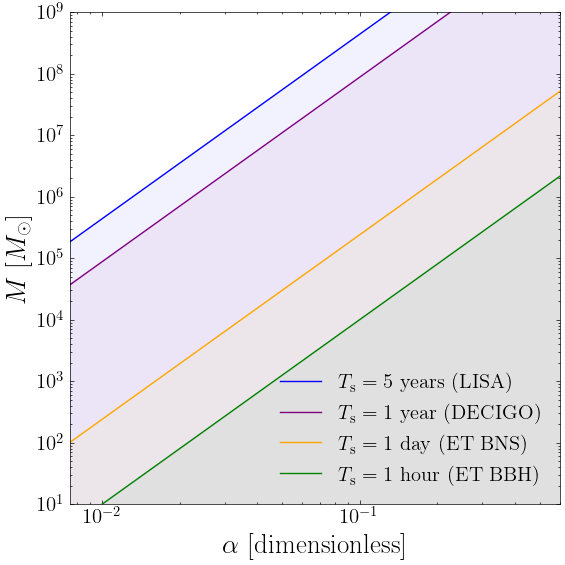

In [7]:
# Independent variables
nPointsGrid = 1000
alphaValues = np.logspace(-3, 0, nPointsGrid)   # dimensionless
MValues = np.logspace(1, 9, nPointsGrid)             # solar masses

# Dependent variables - Analytical expression for the maximum mass 
TsgnLISA = 5 * yr  # seconds   (5 years)
TsgnDECIGO = 1 * yr # seconds   (1 year)
TsgnETbns = 1 * 3600 * 24 # seconds  (1 day)
TsgnETbbh = 1 * 3600 # seconds    (1 hour)

MmaxValuesLISA = 1e6 * (TsgnLISA/(100*3600)) * (alphaValues/0.1)**3   # Tsignal in seconds, alphaValues is dimensionless
MmaxValuesDECIGO = 1e6 * (TsgnDECIGO/(100*3600)) * (alphaValues/0.1)**3   
MmaxValuesETbns = 1e6 * (TsgnETbns/(100*3600)) * (alphaValues/0.1)**3   
MmaxValuesETbbh = 1e6 * (TsgnETbbh/(100*3600)) * (alphaValues/0.1)**3

# Fill regions
fillRegions = [[alphaValues, 1e0, MmaxValuesLISA], [alphaValues, 1e0, MmaxValuesDECIGO], 
               [alphaValues, 1e0, MmaxValuesETbns], [alphaValues, 1e0, MmaxValuesETbbh]]
fillColors = ['blue', 'purple', 'yellow', 'green']
fillAlphas = [0.05, 0.05, 0.05, 0.05]


# Plot
xValues = [alphaValues, alphaValues, alphaValues, alphaValues]
yValues = [MmaxValuesLISA, MmaxValuesDECIGO, MmaxValuesETbns, MmaxValuesETbbh]
plotLabels = [r'$T_\text{s} = 5$ years (LISA)', r'$T_\text{s} = 1$ year (DECIGO)',
              r'$T_\text{s} = 1$ day (ET BNS)', r'$T_\text{s} = 1$ hour (ET BBH)']
LineStyles = ['-', '-', '-', '-']
colors = ["blue", "purple", "orange", "green"]

plot2D = []
contourValues = ''   # [1e12, ...]
contourColors = 'black'
plot2Dcolormap = 'inferno'
plot2DLabel = r'$\Lambda_\text{min}^\text{NPN}$ [dimensionless]'
plot2DScale = 'log'
plot2DMin = 1e-4
plot2DMax = 1
plot2DInv = True
plot2Dalpha = 1

xLines = ''
xLabel = r'$\alpha$ [dimensionless]'
yLabel = r'$M$ [$M_\odot$]'
xScale = 'log'
yScale = 'log'
titleLabel = r""
xMin = 0.0075
xMax = 0.6
yMin = 1e1
yMax = 1e9
legendSize = 0.9

save = False
saveName = "Modulation timescale Mmax (alpha, M) parameter space clean.png"

plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                 contourValues = contourValues, contourColors = contourColors, legendSize = legendSize,
                 fillRegions = fillRegions, fillAlphas = fillAlphas, fillColors = fillColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName)

# 2. Minimum value of $\Lambda$ such that $\Upsilon_\text{Doppler} > \Upsilon_\text{1PN}$ — $\Lambda_\text{min}^\text{1PN}(\alpha, M)$

Need to compare (i) the magnitude of the Doppler effect $\Upsilon_\text{Doppler}$ generated by the coexistence of 322+211 modes

$$\Upsilon_\text{Doppler}(r) \simeq \frac{c}{\omega_\delta} \partial_r (V_{I,0}(r)/c^2)$$

against (ii) the coupling magnitude that the 211 mode alone would generate at first post-Newtonian order

$$\Upsilon_\text{1PN}(r) = V_{211}^\text{1PN}(r) = \frac{\pi}{\mu^2} \rho_{211} (r)$$


We have analytical expressions for both quantities, see Figure below.
 


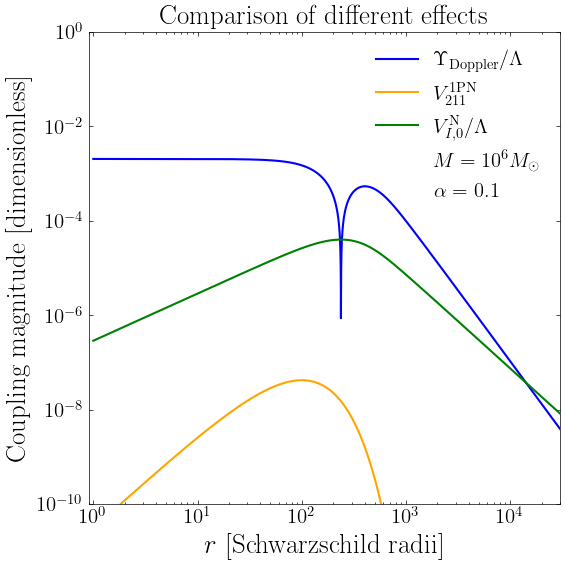

In [5]:

# Parameters of the gravitational atom
M = 1e6  # solar masses
alpha = 0.1  # dimensionless
aTilda = 0.9 # dimensionless
mu = calculate_mu(alpha, M) # eV
Mc = alpha * M   # solar masses 
rS = 2*G*M*Msun/c**2   # SI
rC = rS/(2*alpha**2)   # SI
omega_delta = calculate_omegaDelta211322(mu, alpha, aTilda) # rad/s

# Parameters of the source of GWs
theta_e = np.pi/4   # radians

# Independent variables
nPts = 10000
rVal = np.logspace(0, 6, nPts) * rS # SI


# 1. Doppler coupling magnitude
UpsDop = c/omega_delta * np.abs(calculate_dr_VI(Mc, rVal, rC, theta_e))

# 2. First Post-Newtonian coupling magnitude
a211 = 1
muSI = mu * eV / c**2
Ups1PN = (hbar**2 * G/c**4) * a211 * np.pi/muSI**2 * Mc * Msun/(64 * np.pi * rC**3) * (rVal/rC)**2 * np.exp(-rVal/rC) * np.sin(theta_e)**2 

# 3. Newtonian potential coupling magnitude
UpsPot = calculate_VI(Mc, rVal, rC, theta_e)
    
# Plot - Linear scale, match previous result
xValues = [rVal/rS, rVal/rS, rVal/rS]
yValues = [UpsDop, Ups1PN, UpsPot]
plotLabels = [r"$\Upsilon_\text{{Doppler}}/\Lambda$", r"$V_{{211}}^\text{{1PN}}$", r"$V_{{I, 0}}^\text{{N}}/\Lambda$"]
LineStyles = ['-', '-', '-']
LineWidths = [1.5, 1.5, 1.5]
xLines = []
colors = [""]

xLabel = r'$r$ [Schwarzschild radii]'
yLabel = r'Coupling magnitude [dimensionless]'
xScale = 'log'
yScale = 'log'
textLabels = [r"$M = 10^{{{:.0f}}} M_\odot$".format(int(np.log10(M))), r"$\alpha = {}$".format(alpha)]
titleLabel = 'Comparison of different effects'
xMin = 0.9
xMax = 3e4
yMin = 1e-10
yMax = 1e0
legendSize = 0.9
save = False
saveName = "Different coupling magnitudes comparison 1e{}.png".format(int(np.log10(M)))

plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines, LineWidths = LineWidths, legendSize = legendSize,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName)

We now want to find the minimum $\Lambda$ such that $\Upsilon_\text{doppler} > V_{211}^\text{1PN}$.


$$\Upsilon_\text{Doppler} = \Lambda \times \frac{\Upsilon_\text{Doppler}}{\Lambda} > V_{211}^\text{1PN}$$

so that the boundary on $\Lambda$ is when

$$ \Lambda_\text{min}^\text{1PN} = \frac{V_{211}^\text{1PN}}{\Upsilon_\text{Doppler}/\Lambda}$$

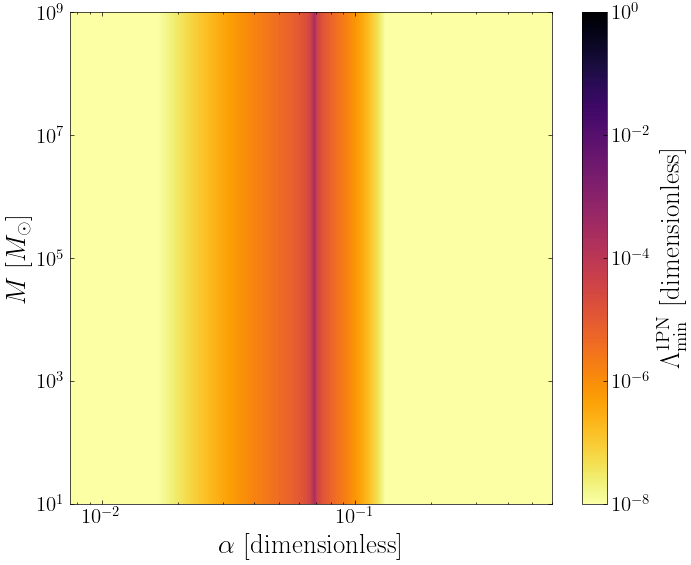

In [3]:
# Parameters of the problem
aTilda = 0.9

# Independent variables
nPointsGrid = 1000
alphaValues = np.logspace(-3, 0, nPointsGrid)   # dimensionless
MValues = np.logspace(1, 9, nPointsGrid)             # solar masses
alphaGrid, MGrid = np.meshgrid(alphaValues, MValues)
muGrid = calculate_mu(alphaGrid, MGrid)   # eV

# Dependent variables - Parameters of the cloud
Mc = alphaGrid * MGrid   # solar masses 
rS = 2*G*MGrid*Msun/c**2   # SI
rC = rS/(2*alphaGrid**2)   # SI
reValue = 500 * rS  # SI
theta_e = np.pi/4 # radians
omega_delta = calculate_omegaDelta211322(muGrid, alphaGrid, aTilda) # rad/s

# Dependent variable - Upsilon/Lambda
UpsDopplerLGrid = c/omega_delta * np.abs(calculate_dr_VI(Mc, reValue, rC, theta_e))
UpsDopplerLGrid[np.where(UpsDopplerLGrid <= 0)] = 1e-20

# Dependent variable - 1PN Potential
a211 = 1
muSI = muGrid * eV / c**2
V211_1PNGrid = (hbar**2 * G/c**4) * a211 * np.pi/muSI**2 * Mc * Msun/(64 * np.pi * rC**3) * (reValue/rC)**2 * np.exp(-reValue/rC) * np.sin(theta_e)**2 

# Dependent variable - Minimum value of Λ
LambdaMinNPN = V211_1PNGrid/UpsDopplerLGrid

# Plot
xValues = [0]
yValues = [0]
plotLabels = ['']
LineStyles = ['']
colors = ["blue"]
plot2D = [alphaGrid, MGrid, LambdaMinNPN]
contourValues = ''   # [1e12, ...]
contourColors = 'black'
plot2Dcolormap = 'inferno'
plot2DLabel = r'$\Lambda_\text{min}^\text{1PN}$ [dimensionless]'
plot2DScale = 'log'
plot2DMin = 1e-8
plot2DMax = 1
plot2DInv = True
plot2Dalpha = 1
xLines = ''
xLabel = r'$\alpha$ [dimensionless]'
yLabel = r'$M$ [$M_\odot$]'
xScale = 'log'
yScale = 'log'
# titleLabel = r"Doppler term $>$ 1PN term"
titleLabel = ''
xMin = 0.0075
xMax = 0.6
yMin = None
yMax = None
save = False
saveName = "NPN LambdaMin (M, alpha) parameter space.png"
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                 contourValues = contourValues, contourColors = contourColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName)

#### This condition will play a minor role compared to the condition of the next section

# 3. Minimum value of $\Lambda$ such that $\text{SNR}_\delta > 1$ — $\Lambda_\text{min}(\alpha, M)$

## 2.2 Signal-to-Noise Ratio above a threshold value $($SNR $>$ SNR$_\text{thresh})$. Condition C3. 

Detectability condition is $\text{SNR}_\delta > 1$, where the signal-to-noise ratio of the modulation effect reads

$$ \text{SNR}_\delta = \text{SNR}_e \left(\frac{\omega_e}{\omega_\delta}\right) \Lambda \frac{\Upsilon(\alpha; r_e)/\Lambda}{\sqrt{2}}$$

with 

$$ \text{SNR}_\delta \sim 1 \text{ (rough threshold for detection)}$$

$$ \text{SNR}_e \sim 1000 \text{ (expected typical GW signal)}$$

$$ \omega_e \sim 10^{-3} \text{ Hz (LISA)} $$

$$ \omega_\delta \sim 10^{-5} \text{ Hz} \text{ (but strong dependence on $\alpha$)}$$

$$\Upsilon_\text{peak}/\Lambda \sim 10^{-3}$$

but $\Upsilon(\alpha)$ presents $\alpha$ dependence. Quick drop at $\alpha \sim 0.2$ for $r_e = 100 r_s$. 

We can invert to obtain the minimum $\Lambda$ needed to achieve SNR$_\delta$ $\sim 1$. 


$$ \Lambda_\text{min}^\text{SNR}(\alpha, M; r_e) = \frac{\text{SNR}_\delta}{\text{SNR}_e} \left(\frac{\omega_\delta(\alpha)}{\omega_e}\right) \frac{\sqrt{2}}{\Upsilon(\alpha; r_e)/\Lambda}$$


Because the parameters $\omega_e$ are expected to be different for LISA and ET and DECIGO, we generate 2 different plots for $\Lambda_\text{min}^\text{SNR}(\alpha, M; r_e)$.


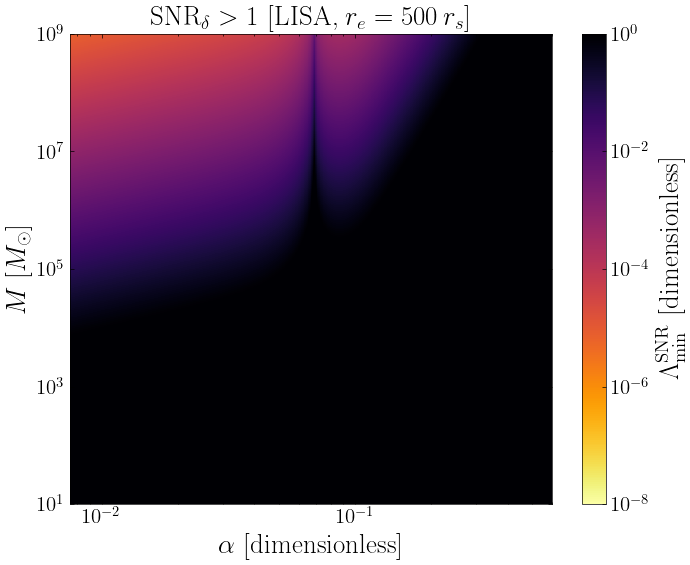

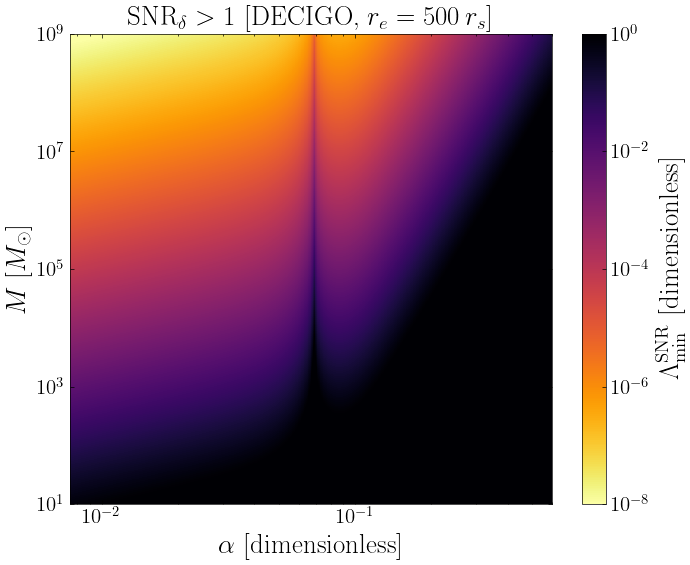

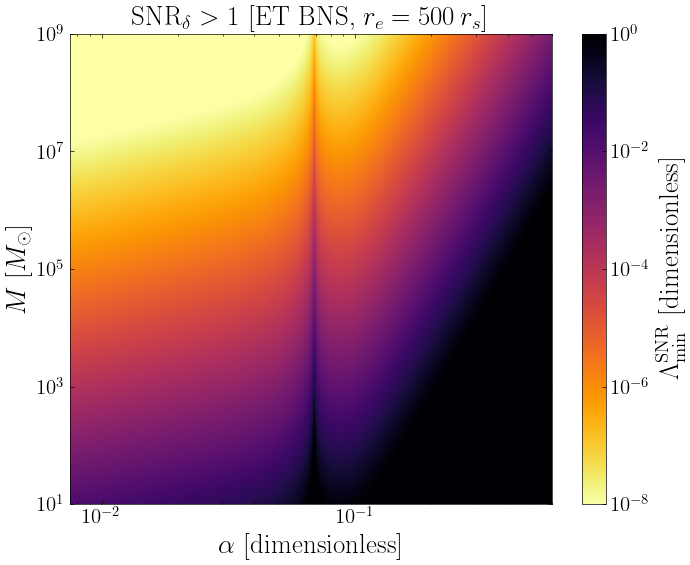

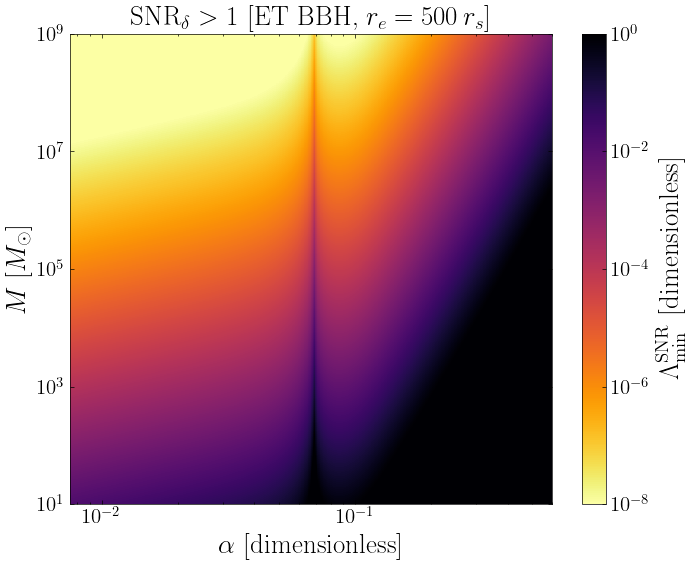

In [3]:
# Parameters of the problem
aTilda = 0.9  # dimensionless - spin of the central BH. 
SNR_delta = 1   # dimensionless - threshold value for the SNR of the modulation effect
theta_e = np.pi/4

# Independent variables
nPointsGrid = 1000
alphaValues = np.logspace(-3, 0, nPointsGrid)   # dimensionless
MValues = np.logspace(1, 9, nPointsGrid)             # solar masses
alphaGrid, MGrid = np.meshgrid(alphaValues, MValues)
muGrid = calculate_mu(alphaGrid, MGrid)   # eV


# Dependent variable - Parameters of the cloud
LambdaMinSNR = np.zeros_like(alphaGrid)
rS = 2*G*MGrid*Msun/c**2     # SI
Mc = alphaGrid * MGrid   # solar masses 
rC = rS/(2*alphaGrid**2)   # SI
omega_delta = calculate_omegaDelta211322(muGrid, alphaGrid, aTilda)  # rad/s

# Loop for different source/detector parameters
numberCases = 4
labelsList = ["LISA", "DECIGO", "ET BNS", "ET BBH"]
omega_e_List = np.array([1e-3, 1e-1, 5, 5])   # Hz
SNR_e_list = [100, 1000, 1000, 1000]   # dimensionless - SNR of the GW carrier event    

reList = np.array([500 * rS, 500 * rS, 500 * rS, 500 * rS])  # SI
LambdaMinSNRList = [np.zeros_like(alphaGrid) for k in range(numberCases)] 



for k in range(numberCases):
    omega_e = omega_e_List[k]
    reValue = reList[k]
    UpsDopplerLGrid = c/omega_delta * np.abs(calculate_dr_VI(Mc, reValue, rC, theta_e))
    UpsDopplerLGrid[np.where(UpsDopplerLGrid <= 0)] = 1e-20

    SNR_e = SNR_e_list[k]
    LambdaMinSNRList[k] = SNR_delta/SNR_e * omega_delta/omega_e * 2**0.5 * 1/UpsDopplerLGrid # dimensionless
    

# Plot 
xValues = [0]
yValues = [0]
plotLabels = ['']
LineStyles = ['']
colors = ["blue"]
contourValues = ''   # [1e12, ...]
contourColors = 'black'
plot2Dcolormap = 'inferno'
plot2DLabel = r'$\Lambda_\text{min}^\text{SNR}$ [dimensionless]'
plot2DScale = 'log'
plot2Dalpha = 1
xLines = ''
xLabel = r'$\alpha$ [dimensionless]'
yLabel = r'$M$ [$M_\odot$]'
xScale = 'log'
yScale = 'log'
xMin = 0.0075
xMax = 0.6
yMin = None
yMax = None

for k in range(numberCases):
    plot2D = [alphaGrid, MGrid, LambdaMinSNRList[k]]
    plot2DMin = 1e-8
    plot2DMax = 1
    plot2DInv = True
    titleLabel = r"SNR$_\delta >$ 1 [{}, $r_e = {} \, r_s$]".format(labelsList[k], int(reList[0][0][0]/rS[0][0]))
    save = False
    saveName = "3 SNR LambdaMin {} (M, alpha) 1e-8 parameter space clean.png".format(labelsList[k])
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                     plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                     plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                     contourValues = contourValues, contourColors = contourColors,
                     xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                     xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName)

Conclusions:

1. SNR > threshold SNR gives a minimum value of $\Lambda$ in $(\alpha, M)$ parameter space.


2. Shape of $\Lambda_\text{min}$ is given by the shape of $\Upsilon$. Minimum $\Lambda$ decreases when $M$ increases, thanks to the smaller $\omega_\delta$ (more carrier cycles per modulation timescale). This dependence on $M$ is not related to $\Upsilon_\text{Doppler}$, which is independent of $M$. 

3. Minimum $\Lambda$ is more restrictive for LISA than for ET and DECIGO, since LISA cycles are longer, thus having less cycles/modulation for a fixed $M$ (fixed modulation timescale).

Conclusions:


1. SNR > 1 and P > PN give lower limits for $\Lambda$. $T_\delta > T_\text{signal}$ gives maximum values for $M$. These conditions leave a final region in parameter space of potential detectability.


Values of $(\alpha, M)$ in this region have 

(i) a doppler term larger than the first post-newtonian  (newtonian is the leading effect), 

(ii) a modulation effect short enough to be observed within the duration of the signal and  (timescales of the effect match)

(iii) a SNR larger than the threshold of 1  (effect is strong enough to be observed).



2. For both LISA and DECIGO, we have significant region where these conditions are satisfied. For ET BNS sources as well. Hope for detectability. Looks good.

# 4. Allowed regions of parameter space using $\Lambda_\text{min}(\alpha, M)$ as $\Lambda_\text{thresh}$

We now have the minimum value of $\Lambda$ as function of the parameter space $(\alpha, M)$ such that the detectability condition is satisfied.

We can use these values of $\Lambda_\text{min}(\alpha, M)$ to find the region of parameter space where coexistence happens for astrophysical timescales, following the discussion of the previous notebooks. We use the physically motivated $\Lambda_\text{min}(\alpha, M)$ instead of the arbitrary parameter $\Lambda_\text{thresh}$.  

We generate the regions of parameter space where the detectability condition is satisfied for both mechanisms: complex scalar fields and self-interacting fields.

## 4.1 Complex scalar field

Gravitational superradiance. No gravitational wave emission. Coexistence during the process of 322 growth and 211 absortion.


**Formation timescale of the coexistence state**


$$ T_F \simeq 1/\Gamma_{322}^\text{sat} \times N_e \text{ if } \Lambda_\text{thresh} < \Lambda_\text{peak} \text{, otherwise } \infty$$

**Coexistence timescale of the state**

$$ T_\text{coex} \simeq 2 \times 1/\Gamma_{322}^\text{sat} \times \Lambda_\text{thresh}^{-0.1} \text{ if } \Lambda_\text{thresh} < \Lambda_\text{peak} \text{, otherwise } 0$$

**Maximum $\Lambda$ reached by the system as function of $\alpha$ and $\tilde{a}_0$**

$$ \log_{10}\Lambda_\text{peak}(\alpha, \tilde{a}) = \frac{0.5}{\log_{10}(2\alpha/\tilde{a})} + \tilde{a} - 1.6$$


C:\Users\Claudi\AppData\Local\Temp\ipykernel_15764\259788997.py:63: RuntimeWarning: overflow encountered in power
  LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)


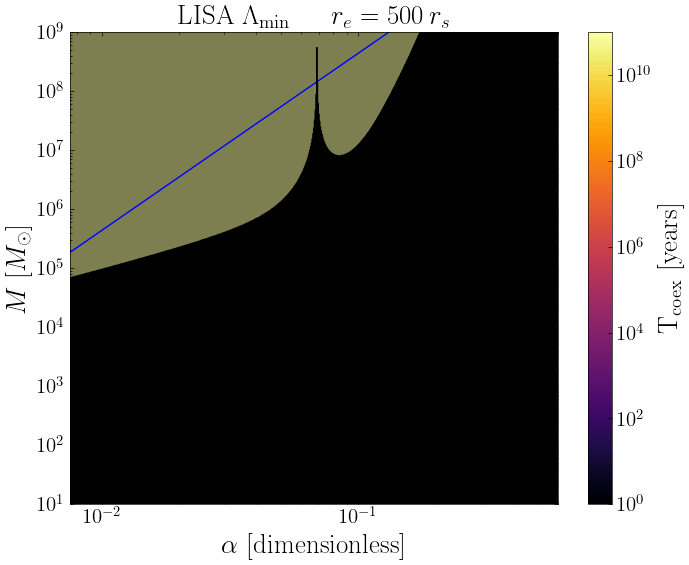

C:\Users\Claudi\AppData\Local\Temp\ipykernel_15764\259788997.py:63: RuntimeWarning: overflow encountered in power
  LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)


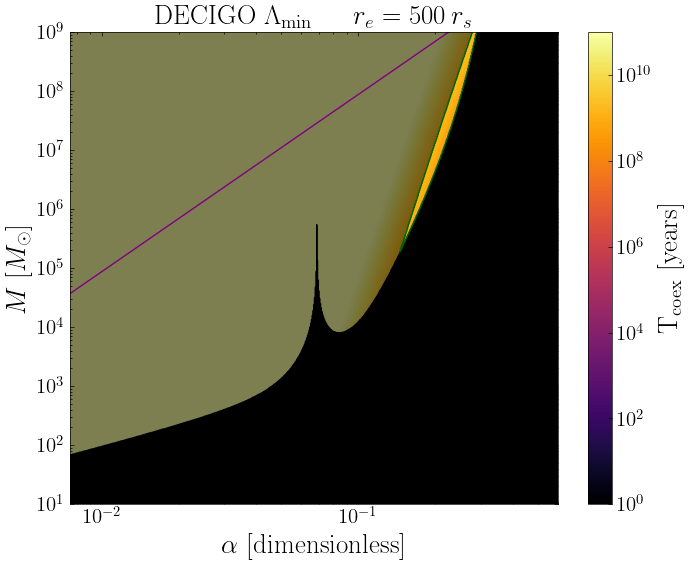

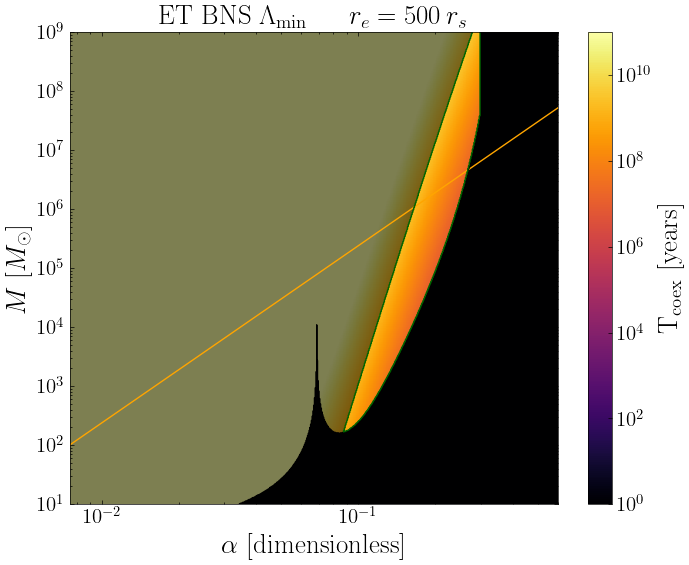

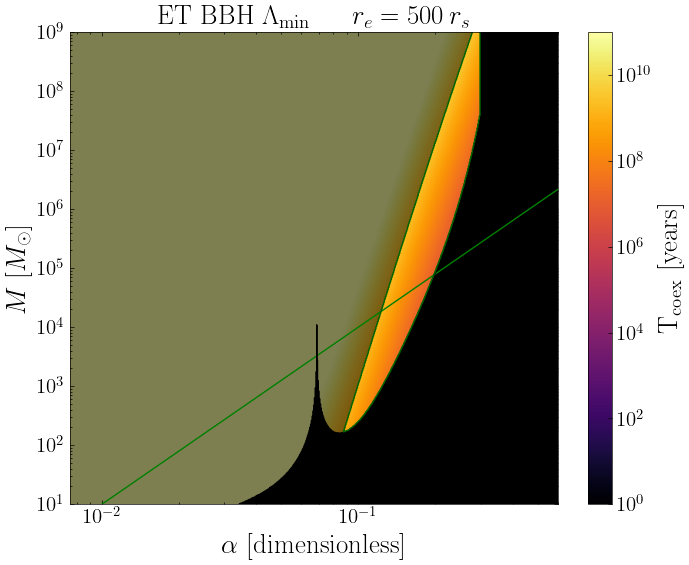

In [3]:
# Parameters of the problem
aTilda0 = 0.9  # dimensionless

# Independent variables. Mass of the ulb and energy scale of self-interaction
nPointsGrid = 1000
alphaValues = np.logspace(-3, 0, nPointsGrid)   # dimensionless
MValues = np.logspace(1, 9, nPointsGrid)             # solar masses
alphaGrid, MGrid = np.meshgrid(alphaValues, MValues)
muGrid = calculate_mu(alphaGrid, MGrid)   # eV


# Dependent variable 1 - Parameters of the cloud
rS = 2*G*MGrid*Msun/c**2     # SI
Mc = alphaGrid * MGrid   # solar masses 
rC = rS/(2*alphaGrid**2)   # SI
omega_delta = calculate_omegaDelta211322(muGrid, alphaGrid, aTilda0)  # rad/s

# Constraints on (α, M) parameters space and Λmin depends on source/detector parameters. Loop over them.
numberCases = 4
labelsList = ["LISA", "DECIGO", "ET BNS", "ET BBH"]
omega_e_List = np.array([1e-3, 1e-1, 5, 5])   # Hz

# Parameters of the source
reList = np.array([500 * rS, 500 * rS, 500 * rS, 500 * rS])  # SI
theta_e = np.pi/4 # radians

SNR_e_list = [100, 1000, 1000, 1000]   # dimensionless - SNR of the GW carrier event    

LambdaMinSNRList = [np.zeros_like(alphaGrid) for k in range(numberCases)] 
LambdaMinNPNList = [np.zeros_like(alphaGrid) for k in range(numberCases)]
LambdaMinList = [np.zeros_like(alphaGrid) for k in range(numberCases)]

# Dependent variable 2 - Maximum mass given by modulation timescale < signal duration 
TsgnList = np.array([5 * yr, 1 * yr, 1 * 3600 * 24, 1 * 3600]) # seconds
MmaxList = np.array([1e6 * (TsgnList[k]/(100*3600)) * (alphaValues/0.1)**3 for k in range(numberCases)]) # solar masses - Tsignal in seconds, alphaValues is dimensionless
colorsList = ["blue", "purple", "orange", "green"]

for k in range(numberCases):
    # Parameters of the gravitational atom system
    SNR_delta = 1   # dimensionless - threshold value for the SNR of the modulation effect
    SNR_e = SNR_e_list[k]   # dimensionless - SNR of the GW carrier event
    omega_e = omega_e_List[k]
    reValue = reList[k]
    UpsDopplerLGrid = c/omega_delta * np.abs(calculate_dr_VI(Mc, reValue, rC, theta_e))
    UpsDopplerLGrid[np.where(UpsDopplerLGrid <= 0)] = 1e-20

    a211 = 1
    muSI = muGrid * eV / c**2
    V211_1PNGrid = (hbar**2 * G/c**4) * a211 * np.pi/muSI**2 * Mc * Msun/(64 * np.pi * rC**3) * (reValue/rC)**2 * np.exp(-reValue/rC) * np.sin(theta_e)**2 
    # Minimum Λ due to SNR
    LambdaMinSNRList[k] = SNR_delta/SNR_e * omega_delta/omega_e * 2**0.5 * 1/UpsDopplerLGrid # dimensionless
    # Minimum Λ due to N > 1PN
    LambdaMinNPNList[k] = V211_1PNGrid/UpsDopplerLGrid
    # Joint minimum Λ
    LambdaMinList[k] = np.max([LambdaMinSNRList[k], LambdaMinNPNList[k]], axis = 0)
    LambdaThreshGrid = LambdaMinList[k]
    
    # Dependent variables
    TfGrid = np.zeros_like(muGrid)
    TcoexGrid = np.zeros_like(muGrid)

    # Coexistence ruled out where Λpeak (maximum we can achieve) < Λmin (minimum that we need) 
    LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)
    LambdaPeakGrid[np.where(alphaGrid > 0.3)] = 1e-20    # erase possibility of coexistence for α > 0.3 

    idxCoex = np.where(LambdaThreshGrid < LambdaPeakGrid)
    idxNoCoex = np.where(LambdaThreshGrid >= LambdaPeakGrid)
    
    aTildaSat211 = 4 * alphaGrid/(1 + 4 * alphaGrid**2)
    
    Nsat = G/(c*hbar) * MGrid**2 * Msun**2   # dimensionless

    # Calculate initial occupation number
    rho_0       = 6.4e6                                                    # density magnitude of the NFW (target) profile [Msun/kpc3]
    R_s         = 20.3                                                     # scale radius of the NFW (target) profile [kpc]
    rC_kpc          = MGrid*Msun/alphaGrid**2 * G/c**2 * 1/(1e3 * pc)          # characteristic scale of the cloud [kpc] 
    rhoTargetrC = calculate_NFW_density(rC_kpc, rho_0, R_s)                    # density of the NFW profile at rC   [Msun/kpc3] 
    Nin_211     = calculate_initial_occupation(2, alphaGrid, MGrid, rhoTargetrC)  # initial occupation number of the mode 211 [dimensionless]
    Nin_322     = calculate_initial_occupation(3, alphaGrid, MGrid, rhoTargetrC)  # initial occupation number of the mode 322 [dimensionless]
    
    
    NeFolds_211 = np.log(Nsat/Nin_211)
    NeFolds_322 = np.log(Nsat/Nin_322)

    NeFolds_211[np.where(NeFolds_211 < 1)] = 1     # impose a minimum of 1 efold (physical reasons)
    NeFolds_322[np.where(NeFolds_322 < 1)] = 1
    
    Gamma322_sat_Grid = calculate_gamma_rate_nlm(3, 2, 2, muGrid, MGrid, aTildaSat211)  # years-1
    # Formation timescale
    TfGrid[idxCoex] =  1/Gamma322_sat_Grid[idxCoex] * NeFolds_322[idxCoex]    # years
    TfGrid[idxNoCoex] = 1e30
    # Coexistence timescale
    TcoexGrid[idxCoex] = 3 * 1/Gamma322_sat_Grid[idxCoex] * LambdaThreshGrid[idxCoex]**(-0.1)   #  years
    TcoexGrid[idxNoCoex] = 1e-10


    # Allowed region
    alphaCond = 0.3  #  dimensionless - Maximum value of alpha
    TeqCond = 1e6   # years   - Minimum value of equilibrium timescale
    TfCond = 1e10    # years   - Maximum value of formation timescale
    alphaCondStr = sci_notation(alphaCond)
    TeCondStr = sci_notation(TeqCond)
    TfCondStr = sci_notation(TfCond)
    allowedGrid = np.zeros_like(muGrid) + 1e-10
    conditionEq = TcoexGrid > TeqCond
    conditionF = TfGrid < TfCond
    conditionAlpha = alphaGrid < alphaCond
    conditionTotal = np.logical_and(np.logical_and(conditionEq, conditionF), conditionAlpha)
    allowedGrid[np.where(conditionTotal)] = 1
    maskedAllowedGrid = np.ma.masked_where(conditionTotal == True, allowedGrid)
    
    
    # Plot - formation timescale
    xValues = [0]
    yValues = [0]
    plotLabels = ['']
    LineStyles = ['']
    textLabels = []
    colors = ["blue"]
    contourValues = [[1e30]]
    contourColors = 'black'
    plot2D = [alphaGrid, MGrid, TfGrid]
    plot2DLabel = r'T$_\text{f}$ [years]'
    plot2DScale = 'log'
    plot2DMin = 1e0
    plot2DMax = 1e11
    plot2DInv = True
    plot2Dcolormap = 'inferno'
    plot2Dalpha = 1
    xLines = ''
    xLabel = r'$\alpha$ [dimensionless]'
    yLabel = r'$M$ [$M_\odot$]'
    xScale = 'log'
    yScale = 'log'
    titleLabel = "Formation timescale {}".format(labelsList[k])
    xMin = 0.0075
    xMax = 0.6
    yMin = None
    yMax = None
    save = False
    saveName = "6 complex {} 1 Formation timescale SNR{}r{}a{}Tf{}Tc{}.png".format(labelsList[k], SNR_delta, int(reValue[0][0]/rS[0][0]), alphaCond, 
                                                                      int(np.log10(TfCond)), int(np.log10(TeqCond)))
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                     plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                     plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                     contourValues = contourValues, contourColors = contourColors,
                     xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                     xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = False)
    
    # Plot - coexistence timescale
    xValues = [0]
    yValues = [0]
    plotLabels = ['']
    LineStyles = ['']
    colors = ["blue"]
    contourValues = [[1]]
    # contourValues = []
    contourColors = 'black'
    plot2D = [alphaGrid, MGrid, TcoexGrid]
    plot2DLabel = r'T$_\text{coex}$ [years]'
    plot2DScale = 'log'
    plot2DMin = 1e0
    plot2DMax = 1e11
    plot2DInv = False
    plot2Dcolormap = 'inferno'
    plot2Dalpha = 1
    xLines = ''
    xLabel = r'$\alpha$ [dimensionless]'
    yLabel = r'$M$ [$M_\odot$]'
    xScale = 'log'
    yScale = 'log'
    titleLabel = "Coexistence timescale {}".format(labelsList[k])
    xMin = 0.0075
    xMax = 0.6
    yMin = 1e1
    yMax = 1e9
    save = False
    saveName = "6 complex {} 2 Coexistence timescale SNR{}r{}a{}Tf{}Tc{}.png".format(labelsList[k], SNR_delta, int(reValue[0][0]/rS[0][0]), alphaCond, 
                                                                      int(np.log10(TfCond)), int(np.log10(TeqCond)))
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                     plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                     plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                     contourValues = contourValues, contourColors = contourColors,
                     xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                     xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = False)
    
    # Plot - allowed region
    xValues = [alphaValues]
    yValues = [MmaxList[k]]
    plotLabels = ['']
    LineStyles = ['-']
    colors = [colorsList[k]]

    plot2D = [[alphaGrid, MGrid, TcoexGrid], [alphaGrid, MGrid, maskedAllowedGrid], [alphaGrid, MGrid, allowedGrid]]
    plot2Dcolormap = ['inferno', 'Greys', 'Greys']
    plot2DLabel = r'T$_\text{coex}$ [years]'
    plot2DScale = ['log', 'linear', 'linear']
    plot2DMin = [1e0, 0, 0]
    plot2DMax = [1e11, 1, 1]
    contourValues = [[1e1], [None], [0.9]]
    contourColors = ['black', 'darkgreen', 'darkgreen']

    plot2DInv = [False, True, False]
    plot2Dalpha = [1, 0.5, 0]
    xLines = []
    titleLabel = r'{} $\Lambda_\text{{min}} $ \ \ \ \  $r_e = {:.0f} \, r_s$'.format(labelsList[k], reValue[0][0]/rS[0][0])
    # titleLabel = ''
    save = False    
    saveName = "Complex {} 3 Allowed region SNR{}r{}a{}Tf{}Tc{}.png".format(labelsList[k], SNR_delta, int(reValue[0][0]/rS[0][0]), alphaCond, 
                                                                      int(np.log10(TfCond)), int(np.log10(TeqCond)))
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                     plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                     plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha = plot2Dalpha,
                     contourValues = contourValues, contourColors = contourColors,
                     xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel,
                     textLabels = textLabels, xLines = xLines,
                     xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = True)

### Complex scalar field in $(M, \mu)$ parameter space

C:\Users\Claudi\AppData\Local\Temp\ipykernel_2044\942081586.py:43: RuntimeWarning: divide by zero encountered in divide
  UpsDopplerLGrid = c/omega_delta * np.abs(calculate_dr_VI(Mc, reValue, rC, theta_e))
C:\Users\Claudi\AppData\Local\Temp\ipykernel_2044\942081586.py:62: RuntimeWarning: overflow encountered in power
  LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)
C:\Users\Claudi\AppData\Local\Temp\ipykernel_2044\942081586.py:91: RuntimeWarning: divide by zero encountered in power
  TcoexGrid[idxCoex] = 3 * 1/Gamma322_sat_Grid[idxCoex] * LambdaThreshGrid[idxCoex]**(-0.1)   #  years


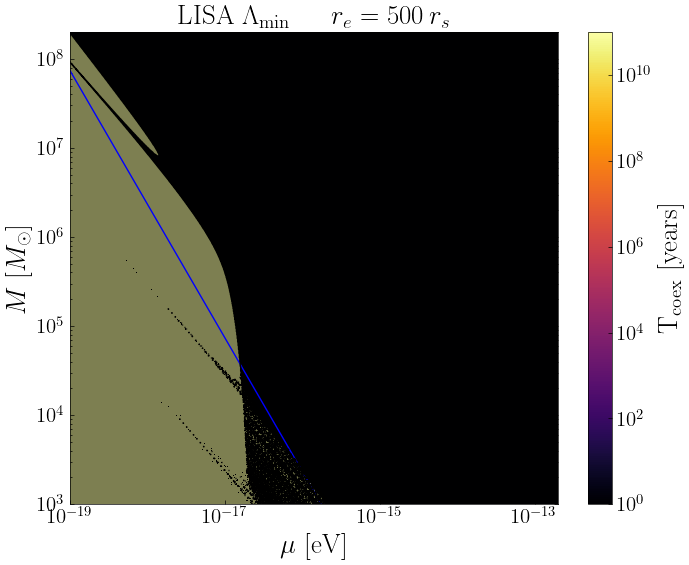

C:\Users\Claudi\AppData\Local\Temp\ipykernel_2044\942081586.py:43: RuntimeWarning: divide by zero encountered in divide
  UpsDopplerLGrid = c/omega_delta * np.abs(calculate_dr_VI(Mc, reValue, rC, theta_e))
C:\Users\Claudi\AppData\Local\Temp\ipykernel_2044\942081586.py:62: RuntimeWarning: overflow encountered in power
  LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)
C:\Users\Claudi\AppData\Local\Temp\ipykernel_2044\942081586.py:91: RuntimeWarning: divide by zero encountered in power
  TcoexGrid[idxCoex] = 3 * 1/Gamma322_sat_Grid[idxCoex] * LambdaThreshGrid[idxCoex]**(-0.1)   #  years


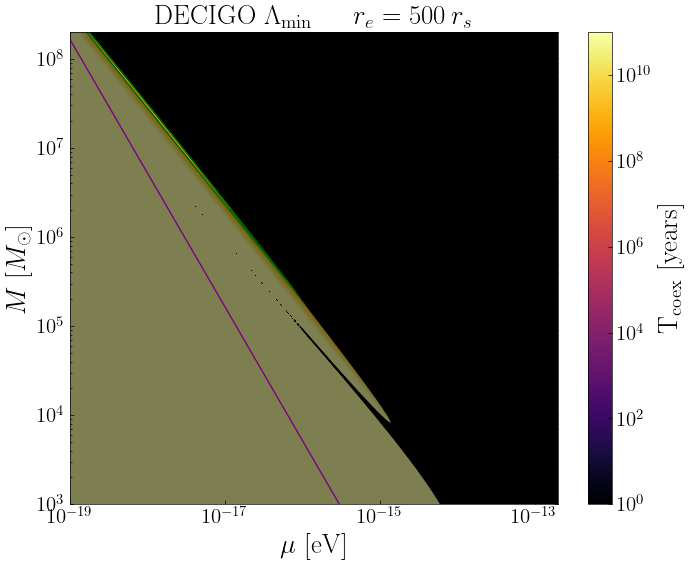

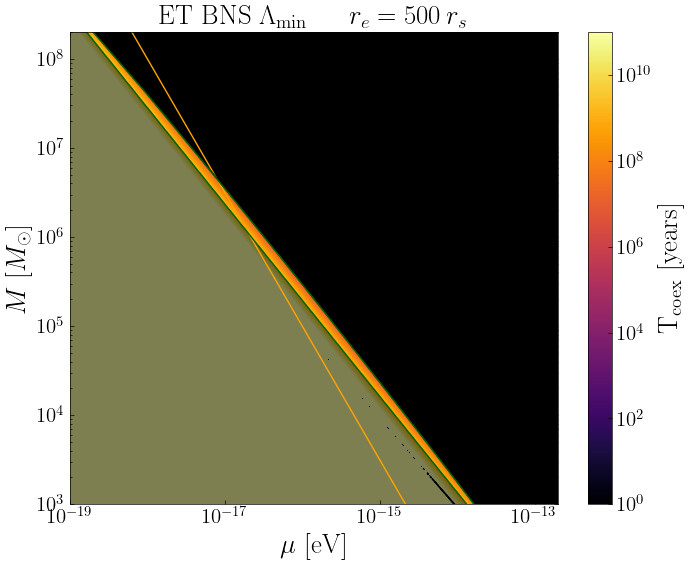

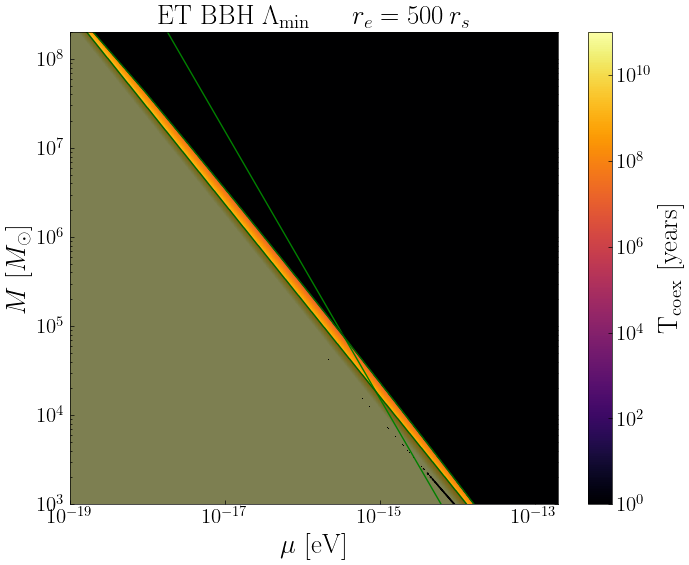

In [3]:
# Parameters of the problem
aTilda0 = 0.9  # dimensionless

# Independent variables. Mass of the ulb and energy scale of self-interaction
nPointsGrid = 2000
muValues = np.logspace(np.log10(1.336e-22), np.log10(1.336e-11), nPointsGrid)   # dimensionless
MValues = np.logspace(1, 9, nPointsGrid)             # solar masses
muGrid, MGrid = np.meshgrid(muValues, MValues)
alphaGrid = calculate_alpha(muGrid, MGrid)   # eV


# Dependent variable 1 - Parameters of the cloud
rS = 2*G*MGrid*Msun/c**2     # SI
Mc = alphaGrid * MGrid   # solar masses 
rC = rS/(2*alphaGrid**2)   # SI
omega_delta = calculate_omegaDelta211322(muGrid, alphaGrid, aTilda0)  # rad/s

# Constraints on (μ, M) parameters space and Λmin depends on source/detector parameters. Loop over them.
numberCases = 4
labelsList = ["LISA", "DECIGO", "ET BNS", "ET BBH"]
omega_e_List = np.array([1e-3, 1e-1, 5, 5])   # Hz

# Parameters of the GW source
reList = np.array([500 * rS, 500 * rS, 500 * rS, 500 * rS])  # SI
theta_e = np.pi/4  # rad/s

SNR_e_list = [100, 1000, 1000, 1000]   # dimensionless - SNR of the GW carrier event    
LambdaMinSNRList = [np.zeros_like(alphaGrid) for k in range(numberCases)] 
LambdaMinNPNList = [np.zeros_like(alphaGrid) for k in range(numberCases)]
LambdaMinList = [np.zeros_like(alphaGrid) for k in range(numberCases)]

# Dependent variable 2 - Maximum mass given by modulation timescale < signal duration 
TsgnList = np.array([5 * yr, 1 * yr, 1 * 3600 * 24, 1 * 3600]) # seconds
MmaxList = np.array([1e6 * (TsgnList[k]/(100*3600))**(-0.5) * (muValues/1.34e-17)**(-3/2) for k in range(numberCases)]) # solar masses - Tsignal in seconds, alphaValues is dimensionless
colorsList = ["blue", "purple", "orange", "green"]

for k in range(numberCases):
    # Parameters of the gravitational atom system
    SNR_delta = 1   # dimensionless - threshold value for the SNR of the modulation effect
    SNR_e = SNR_e_list[k]   # dimensionless - SNR of the GW carrier event
    omega_e = omega_e_List[k]
    reValue = reList[k]
    UpsDopplerLGrid = c/omega_delta * np.abs(calculate_dr_VI(Mc, reValue, rC, theta_e))
    UpsDopplerLGrid[np.where(UpsDopplerLGrid <= 0)] = 1e-20
    
    a211 = 1
    muSI = muGrid * eV / c**2
    V211_1PNGrid = (hbar**2 * G/c**4) * a211 * np.pi/muSI**2 * Mc * Msun/(64 * np.pi * rC**3) * (reValue/rC)**2 * np.exp(-reValue/rC) * np.sin(theta_e)**2 
    # Minimum Λ due to SNR
    LambdaMinSNRList[k] = SNR_delta/SNR_e * omega_delta/omega_e * 2**0.5 * 1/UpsDopplerLGrid # dimensionless
    # Minimum Λ due to N > 1PN
    LambdaMinNPNList[k] = V211_1PNGrid/UpsDopplerLGrid
    # Joint minimum Λ
    LambdaMinList[k] = np.max([LambdaMinSNRList[k], LambdaMinNPNList[k]], axis = 0)
    LambdaThreshGrid = LambdaMinList[k]
    
    # Dependent variables
    TfGrid = np.zeros_like(muGrid)
    TcoexGrid = np.zeros_like(muGrid)
    
    # Coexistence ruled out where Λpeak (maximum we can achieve) < Λmin (minimum that we need) 
    LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)
    LambdaPeakGrid[np.where(alphaGrid > 0.3)] = 1e-20    # erase possibility of coexistence for α > 0.3 
    
    idxCoex = np.where(np.logical_and(LambdaThreshGrid < LambdaPeakGrid, alphaGrid < 0.3))
    idxNoCoex = np.where(np.logical_or(LambdaThreshGrid >= LambdaPeakGrid, alphaGrid >= 0.3))
    
    aTildaSat211 = 4 * alphaGrid/(1 + 4 * alphaGrid**2)
    Nsat = G/(c*hbar) * MGrid**2 * Msun**2   # dimensionless
    
    # Calculate initial occupation number
    rho_0       = 6.4e6                                                    # density magnitude of the NFW (target) profile [Msun/kpc3]
    R_s         = 20.3                                                     # scale radius of the NFW (target) profile [kpc]
    rC_kpc      = MGrid*Msun/alphaGrid**2 * G/c**2 * 1/(1e3 * pc)          # characteristic scale of the cloud [kpc] 
    rhoTargetrC = calculate_NFW_density(rC_kpc, rho_0, R_s)                    # density of the NFW profile at rC   [Msun/kpc3] 
    Nin_211     = calculate_initial_occupation(2, alphaGrid, MGrid, rhoTargetrC)  # initial occupation number of the mode 211 [dimensionless]
    Nin_322     = calculate_initial_occupation(3, alphaGrid, MGrid, rhoTargetrC)  # initial occupation number of the mode 322 [dimensionless]
    
    
    NeFolds_211 = np.log(Nsat/Nin_211)
    NeFolds_322 = np.log(Nsat/Nin_322)
    
    NeFolds_211[np.where(NeFolds_211 < 1)] = 1     # impose a minimum of 1 efold (physical reasons)
    NeFolds_322[np.where(NeFolds_322 < 1)] = 1
    
    Gamma322_sat_Grid = calculate_gamma_rate_nlm(3, 2, 2, muGrid, MGrid, aTildaSat211)  # years-1
    # Formation timescale
    TfGrid[idxCoex] =  1/Gamma322_sat_Grid[idxCoex] * NeFolds_322[idxCoex]    # years
    TfGrid[idxNoCoex] = 1e30
    # Coexistence timescale
    TcoexGrid[idxCoex] = 3 * 1/Gamma322_sat_Grid[idxCoex] * LambdaThreshGrid[idxCoex]**(-0.1)   #  years
    TcoexGrid[idxNoCoex] = 1e-10
    
    
    # Allowed region
    alphaCond = 0.3  #  dimensionless - Maximum value of alpha
    TeqCond = 1e6   # years   - Minimum value of equilibrium timescale
    TfCond = 1e10    # years   - Maximum value of formation timescale
    alphaCondStr = sci_notation(alphaCond)
    TeCondStr = sci_notation(TeqCond)
    TfCondStr = sci_notation(TfCond)
    allowedGrid = np.zeros_like(muGrid) + 1e-10
    conditionEq = TcoexGrid > TeqCond
    conditionF = TfGrid < TfCond
    conditionAlpha = alphaGrid < alphaCond
    conditionTotal = np.logical_and(np.logical_and(conditionEq, conditionF), conditionAlpha)
    allowedGrid[np.where(conditionTotal)] = 1
    maskedAllowedGrid = np.ma.masked_where(conditionTotal == True, allowedGrid)
    
    
    # Plot - formation timescale
    xValues = [0]
    yValues = [0]
    plotLabels = ['']
    LineStyles = ['']
    textLabels = []

    colors = ["blue"]
    contourValues = [[1e30]]
    contourColors = 'black'
    plot2D = [muGrid, MGrid, TfGrid]
    plot2DLabel = r'T$_\text{f}$ [years]'
    plot2DScale = 'log'
    plot2DMin = 1e0
    plot2DMax = 1e11
    plot2DInv = True
    plot2Dcolormap = 'inferno'
    plot2Dalpha = 1
    xLines = ''
    xLabel = r'$\mu$ [eV]'
    yLabel = r'$M$ [$M_\odot$]'
    xScale = 'log'
    yScale = 'log'
    titleLabel = "Formation timescale {}".format(labelsList[k])
    xMin = 1e-19
    xMax = 2e-13
    yMin = 1e3
    yMax = 2e8
    save = False
    saveName = "6 complex (mu M) {} 1 Formation timescale SNR{}r{}a{}Tf{}Tc{}.png".format(labelsList[k], SNR_delta, int(reValue[0][0]/rS[0][0]), alphaCond, 
                                                                      int(np.log10(TfCond)), int(np.log10(TeqCond)))
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                     plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                     plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                     contourValues = contourValues, contourColors = contourColors,
                     xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                     xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = False)
    
    # Plot - coexistence timescale
    xValues = [0]
    yValues = [0]
    plotLabels = ['']
    LineStyles = ['']
    colors = ["blue"]
    contourValues = [[1]]
    # contourValues = []
    contourColors = 'black'
    plot2D = [muGrid, MGrid, TcoexGrid]
    plot2DLabel = r'T$_\text{coex}$ [years]'
    plot2DScale = 'log'
    plot2DMin = 1e0
    plot2DMax = 1e11
    plot2DInv = False
    plot2Dcolormap = 'inferno'
    plot2Dalpha = 1
    xLines = ''
    xLabel = r'$\mu$ [eV]'
    yLabel = r'$M$ [$M_\odot$]'
    xScale = 'log'
    yScale = 'log'
    titleLabel = "Coexistence timescale {}".format(labelsList[k])
    xMin = 1e-19
    xMax = 2e-13
    yMin = 1e3
    yMax = 2e8
    save = False
    saveName = "6 complex (mu M) {} 2 Coexistence timescale SNR{}r{}a{}Tf{}Tc{}.png".format(labelsList[k], SNR_delta, int(reValue[0][0]/rS[0][0]), alphaCond, 
                                                                      int(np.log10(TfCond)), int(np.log10(TeqCond)))
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                     plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                     plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                     contourValues = contourValues, contourColors = contourColors,
                     xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                     xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = False)
    
    # Plot - allowed region
    xValues = [muValues]
    yValues = [MmaxList[k]]
    plotLabels = ['']
    LineStyles = ['-']
    colors = [colorsList[k]]
    
    plot2D = [[muGrid, MGrid, TcoexGrid], [muGrid, MGrid, maskedAllowedGrid], [muGrid, MGrid, allowedGrid]]
    plot2Dcolormap = ['inferno', 'Greys', 'Greys']
    plot2DLabel = r'T$_\text{coex}$ [years]'
    plot2DScale = ['log', 'linear', 'linear']
    plot2DMin = [1e0, 0, 0]
    plot2DMax = [1e11, 1, 1]
    contourValues = [[1e1], [None], [0.9]]
    contourColors = ['black', 'darkgreen', 'darkgreen']

    plot2DInv = [False, True, False]
    plot2Dalpha = [1, 0.5, 0]
    xLines = []
    titleLabel = r'{} $\Lambda_\text{{min}} $ \ \ \ \  $r_e = {:.0f} \, r_s$'.format(labelsList[k], reValue[0][0]/rS[0][0])
    # titleLabel = r''
    save = False
    
    saveName = "Complex (mu M) {} 3 Allowed region SNR{}r{}a{}Tf{}Tc{}.png".format(labelsList[k], SNR_delta, int(reValue[0][0]/rS[0][0]), alphaCond, 
                                                                      int(np.log10(TfCond)), int(np.log10(TeqCond)))
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                     plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                     plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha = plot2Dalpha,
                     contourValues = contourValues, contourColors = contourColors, 
                     xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel,
                     textLabels = textLabels, xLines = xLines,
                     xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = True)
    


## 4.2 Self-interacting scalar fields

Superradiance of self-interacting ultralight bosons. Interactions between the cloud. Interactions allow coexistence between the $211$ and $322$ modes.


**Formation timescale of the coexistence state**

$$  T_F = \tau_{211} + t_*$$

**Coexistence timescale of the state**

$$ T_\text{coex} = \text{min}\{1/\Gamma_\text{SR}^{322} \times \log(\eta^{-1}), \chi(\Lambda_\text{thresh}) \times \tau_\text{scalar}\}$$


C:\Users\Claudi\AppData\Local\Temp\ipykernel_12596\3131971932.py:139: RuntimeWarning: invalid value encountered in sqrt
  eps211Max = (1 - 8*alphaGrid**2 + 8*alphaGrid**3*aTilda - (1 - 16*alphaGrid**2 + 32*alphaGrid**3*aTilda - 16*alphaGrid**4*aTilda**2)**0.5)/(8*(-alphaGrid**3 + alphaGrid**4*aTilda)) # dimensionless, O(α^2), valid for α <= 0.3


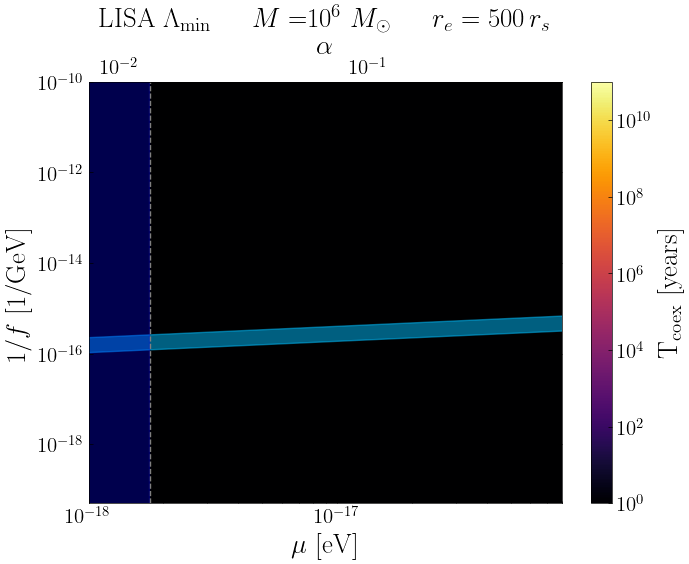

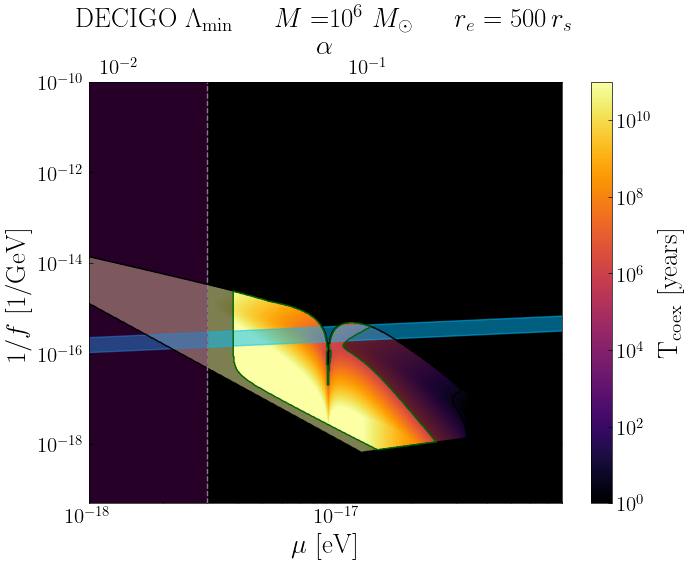

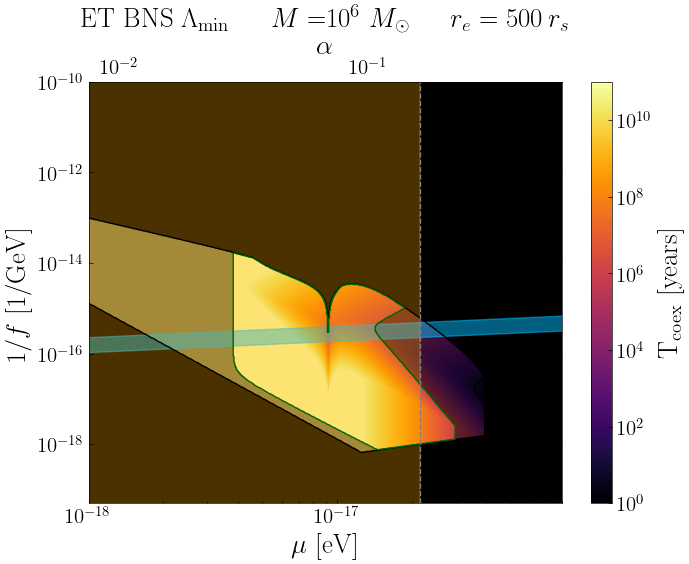

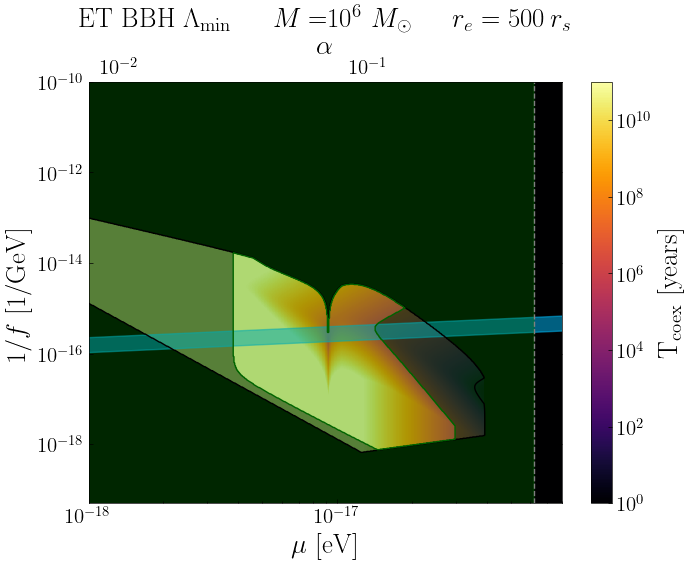

In [7]:
# MValues = np.array([1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9])
MValues = np.array([1e6])

for M in MValues:
    # Parameters of the gravitational atom system
    aTilda = 0.9  # dimensionless spin of the black hole - dimensionless
    TBH = 1e10  #  accretion timescale of the black hole - years
    kappaBH = 4e-7    # dimensionless amplitude of the rate of the process 211, 211 -> 322, BH
    SNR_delta = 1   # dimensionless - threshold value for the SNR of the modulation effect

    # Independent variables. Mass of the ulb and energy scale of self-interaction
    nPointsGrid = 1000
    alphaValues = np.logspace(-3, 0, nPointsGrid) # gravitational coupling constant - dimensionless
    muValues = calculate_mu(alphaValues, M)  # mass of the ultralight boson - eV
    fValues = np.logspace(10, 20, nPointsGrid)  # energy scale of symmetry breaking - GeV
    muGrid, fGrid = np.meshgrid(muValues, fValues)
    alphaGrid = calculate_alpha(muGrid, M)
    
    ### Boundaries 
    fABValues = np.min([3e16 * (TBH/1e10)**(1/4) * (muValues/1e-13)**(1/4) * (alphaValues/0.01)**(11/4), 
                  8e18 * (0.01/alphaValues)**(3/4) * (aTilda/0.9)**(1/4)], axis = 0)
    fBCValues = 2e16 * (aTilda/0.9)**(1/4) * np.min([(alphaValues/0.04)**(3/4), 
                                                     (alphaValues/0.04)**(3/2)], axis = 0)
    fCDValues = 3e14 * (1e10/TBH)**(1/2) * (1e-13/muValues)**(1/2) * (0.01/alphaValues)**(5/2) * (0.9/aTilda)**(3/4)
    fABGrid = np.min([3e16 * (TBH/1e10)**(1/4) * (muGrid/1e-13)**(1/4) * (alphaGrid/0.01)**(11/4), 
                  8e18 * (0.01/alphaGrid)**(3/4) * (aTilda/0.9)**(1/4)], axis = 0)
    fBCGrid = 2e16 * (aTilda/0.9)**(1/4) * np.min([(alphaGrid/0.04)**(3/4), 
                                                     (alphaGrid/0.04)**(3/2)], axis = 0)
    fCDGrid = 3e14 * (1e10/TBH)**(1/2) * (1e-13/muGrid)**(1/2) * (0.01/alphaGrid)**(5/2) * (0.9/aTilda)**(3/4)
    idxA = np.where(fGrid > fABGrid)
    idxB = np.where(np.logical_and(fABGrid > fGrid, fGrid > fBCGrid))   # recall that Fig 4 is showing 1/f (!)
    idxC = np.where(np.logical_and(fABGrid > fGrid, fGrid < fBCGrid)) 
    idxD = np.where(np.logical_and(np.logical_and(fABGrid > fGrid, fGrid < fBCGrid), fGrid < fCDGrid))
    
    
    ### QCD Axion
    fValuesQCD = 1e18 * (6e-12/muValues)  # GeV
    
    ### Dark matter abundance band
    fValuesDM = 3e15 * (1e-16/muValues)**(1/4)  # GeV  - Cosmic abundance of DM. Lower bound of the narrow band. a_init = f  
    fValuesDMNarrowHigh = fValuesDM/(np.pi - 1)  # GeV  - Cosmic abundance of DM. Upper bound of the narrow band. a_init = f/(pi - 1)
    
    ### Dependent variables
    rS = 2*G*M*Msun/c**2     # SI
    Mc = alphaGrid * M   # solar masses 
    rC = rS/(2*alphaGrid**2)   # SI
    omega_delta = calculate_omegaDelta211322(muGrid, alphaGrid, aTilda)  # rad/s

    ## 1. Qualitatively different regions
    fillRegions = [[muValues, 1/fValuesDMNarrowHigh, 1/fValuesDM], [muValues, 1/fABValues, 1e-20], [muValues, 1/fBCValues, 1/fABValues], 
                  [muValues, 1/fCDValues, 1/fBCValues], [muValues, 1e-9, 1/fCDValues]]
    fillColors = ['deepskyblue', 'grey', 'brown', 'green', 'orange']
    fillAlphas = [0.5, 0.2, 0.2, 0.2, 0.2]
    # Plot
    xValues = [muValues, muValues, muValues, muValues, muValues, muValues]
    yValues = [1/fValuesDM, 1/fValuesDMNarrowHigh, 1/fValuesQCD, 1/fABValues, 1/fBCValues, 1/fCDValues]
    plotLabels = ''
    LineStyles = ['-', '-', '-', '-', '-', '-']
    colors = ["deepskyblue", "deepskyblue", 'blue', 'brown', 'green', 'orange']
    textLabels = [r"$M = 10^{{{:.0f}}} M_\odot$".format(int(np.log10(M))), r"$a_* = {}$".format(aTilda),
                 r"$T_\text{{BH}} = 10^{{{:.0f}}}$ yr".format(int(np.log10(TBH)))]
    xLabel = r'$\mu$ [eV]'
    x2Label = r'$\alpha$'
    yLabel = r'$1/f$ [1/GeV]'
    xScale = 'log'
    yScale = 'log'
    x2Fun = lambda x: G/(c*hbar) * x * eV/c**2 * M * Msun
    x2FunInv = lambda x: c*hbar/G * c**2/eV * 1/(M * Msun) * x
    xMin = 1e-18 * (1e6/M)
    xMax = 8e-17 * (1e6/M)
    yMin = 5e-20
    yMax = 1e-10
    save = False
    saveName = "6 0 Parameter space regions 1e{}.png".format(int(np.log10(M)))
    plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale,
                    x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, textLabels = textLabels,
                    fillRegions = fillRegions, fillAlphas = fillAlphas, fillColors = fillColors,
                    save = save, saveName = saveName, show = False)

    #### Constraints on (α, M) parameters space and Λmin depends on source/detector parameters. Loop over them.
    numberCases = 4
    labelsList = ["LISA", "DECIGO", "ET BNS", "ET BBH"]
    omega_e_List = np.array([1e-3, 1e-1, 5, 5])   # Hz
    SNR_e_list = [100, 1000, 1000, 1000]   # dimensionless - SNR of the GW carrier event
    theta_e = np.pi/4 # rad/s
    reList = np.array([500 * rS, 500 * rS, 500 * rS, 500 * rS])  # SI
    LambdaMinSNRList = [np.zeros_like(alphaGrid) for k in range(numberCases)] 
    LambdaMinNPNList = [np.zeros_like(alphaGrid) for k in range(numberCases)]
    LambdaMinList = [np.zeros_like(alphaGrid) for k in range(numberCases)]

    # Dependent variable 2 - Maximum mass given by modulation timescale < signal duration 
    TsgnList = np.array([5 * yr, 1 * yr, 1 * 3600 * 24, 1 * 3600]) # seconds
    alphaMinSgnList = np.array([0.1 * (100 * 3600/TsgnList[k])**(1/3) * (M/1e6)**(1/3) for k in range(numberCases)])  # dimensionless, Tsgn in seconds, M in solar masses  
    colorsList = ["blue", "purple", "orange", "green"]

    for k in range(numberCases):
        omega_e = omega_e_List[k]
        reValue = reList[k]
        UpsDopplerLGrid = c/omega_delta * np.abs(calculate_dr_VI(Mc, reValue, rC, theta_e))
        UpsDopplerLGrid[np.where(UpsDopplerLGrid <= 0)] = 1e-20
    
        a211 = 1
        muSI = muGrid * eV / c**2
        V211_1PNGrid = (hbar**2 * G/c**4) * a211 * np.pi/muSI**2 * Mc * Msun/(64 * np.pi * rC**3) * (reValue/rC)**2 * np.exp(-reValue/rC) * np.sin(theta_e)**2 
        # Minimum Λ due to SNR
        SNR_e = SNR_e_list[k]
        LambdaMinSNRList[k] = SNR_delta/SNR_e * omega_delta/omega_e * 2**0.5 * 1/UpsDopplerLGrid # dimensionless
        # Minimum Λ due to N > 1PN
        LambdaMinNPNList[k] = V211_1PNGrid/UpsDopplerLGrid
        # Joint minimum Λ
        LambdaMinList[k] = np.max([LambdaMinSNRList[k], LambdaMinNPNList[k]], axis = 0)
    
        # All following plots
        xValues = [0]
        yValues = [0]
        plotLabels = ['']
        LineStyles = ['']
        colors = ["blue"]
        plot2Dcolormap = 'inferno'
        plot2DScale = 'log'
        plot2Dalpha = 1
        xLines = ''
        xLabel = r'$\mu$ [eV]'
        x2Label = r'$\alpha$'
        yLabel = r'$1/f$ [1/GeV]'
        xScale = 'log'
        yScale = 'log'
        textLabels = [r"$M = 10^{{{:.0f}}} M_\odot$".format(int(np.log10(M))), r"$a_* = {}$".format(aTilda)]
        legendSize = 0.9
        x2Fun = lambda x: G/(c*hbar) * x * eV/c**2 * M * Msun
        x2FunInv = lambda x: c*hbar/G * c**2/eV * 1/(M * Msun) * x
        xMin = 1e-18 * (1e6/M)
        xMax = 8e-17 * (1e6/M)
        yMin = 5e-20
        yMax = 1e-10
        
        # Parameters to compute timescales
        rTildePlus = 1 + (1 - aTilda**2)**0.5  # dimensionless
        eps211Max = (1 - 8*alphaGrid**2 + 8*alphaGrid**3*aTilda - (1 - 16*alphaGrid**2 + 32*alphaGrid**3*aTilda - 16*alphaGrid**4*aTilda**2)**0.5)/(8*(-alphaGrid**3 + alphaGrid**4*aTilda)) # dimensionless, O(α^2), valid for α <= 0.3
        eps211Max[np.where(alphaGrid > 0.3)] = 1e-20
        etaGrid = np.zeros_like(alphaGrid)
        etaGrid = 4e-5 * (alphaGrid/0.01)**3  # dimensionless, leading order of α
        etaGrid[idxA] = 1/np.exp(180) # dimensionless - numerical zero, we want to avoid zero for the log scale
        
        epsRatioGrid = np.zeros_like(alphaGrid)
        epsRatioGrid[idxA] = 1
        epsRatioGrid[idxB] = 1
        epsRatioGrid[idxC] = (fGrid[idxC]/fBCGrid[idxC])**2
        epsRatioGrid[idxD] = (fGrid[idxD]/fBCGrid[idxD])**2
        
        eps211Peak = epsRatioGrid * eps211Max
        LambdaPeakGrid = eps211Max * epsRatioGrid * (etaGrid)**0.5 
        idxCoex = np.where(LambdaPeakGrid >= LambdaMinList[k])
        idxNoCoex = np.where(LambdaPeakGrid < LambdaMinList[k])

        
        ## 2. Formation timescale
        TfGrid = np.zeros_like(muGrid)
        # Calculate number of e-folds from the initial occupation number
        Nsat = G/(c*hbar) * M**2 * Msun**2   # number of particles that the cloud reaches when saturated [dimensionless]
        rho_0       = 6.4e6                                                    # density magnitude of the NFW (target) profile [Msun/kpc3]
        R_s         = 20.3                                                     # scale radius of the NFW (target) profile [kpc]
        rC_kpc      = M*Msun/alphaGrid**2 * G/c**2 * 1/(1e3 * pc)                 # characteristic scale of the cloud [kpc] 
        rhoTargetrC = calculate_NFW_density(rC_kpc, rho_0, R_s)                    # density of the NFW profile at rC   [Msun/kpc3] 
        Nin_211     = calculate_initial_occupation(2, alphaGrid, M, rhoTargetrC)  # initial occupation number of the mode 211 [dimensionless]
        NeFolds211 = np.log(Nsat/Nin_211) # dimensionless

        Tf211Grid = calculate_growth_timescale(2, 1, 1, muGrid, M, aTilda) * NeFolds211
        Tf211Grid[np.where(Tf211Grid <= 0)] = 1e-15
        TFnoneqGrid = G*M*Msun/c**3 * 1/yr * np.log(G/(c*hbar) * M**2 * Msun**2)/(kappaBH * rTildePlus * alphaGrid**12 * (Mpl/fGrid)**4 * eps211Max**2) # years   
        TfGrid[idxCoex] = Tf211Grid[idxCoex] + TFnoneqGrid[idxCoex]
        TfGrid[idxNoCoex] = 1e30
        # Plot
        plot2D = [muGrid, 1/fGrid, TfGrid]
        contourValues = [1e12]
        contourColors = 'black'
        plot2DLabel = r'T$_\text{F}$ [years]'
        plot2DMin = 1e0
        plot2DMax = 1e11
        plot2DInv = True
        titleLabel = ''
        save = False
        saveName = "5 SIB {} 1 Formation timescale coex M{:.1f}TBH{}SNR{}r{}.png".format(labelsList[k], np.log10(M), int(np.log10(TBH)), SNR_delta, int(reValue/rS))
        plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                         plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                         plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                         contourValues = contourValues, contourColors = contourColors,
                         xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, legendSize = legendSize,
                         x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, textLabels = textLabels, xLines = xLines,
                         xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = False)
    
        # 3. Equilibrium timescale
        TeqGrid = np.zeros_like(muGrid)
        TScalar = 1e-1 * (0.1/alphaGrid)**(14) * (1e-12/muGrid) * (fGrid/1e17)**4 # years
        nFolds = 1/(2 * eps211Peak**2) * ((LambdaPeakGrid/LambdaMinList[k])**2 - 1)
        nFolds[np.where(nFolds <= 0)] = -1
        TScalarThresh = nFolds * TScalar   # years
        T322Mod = calculate_growth_timescale(3, 2, 2, muGrid, M, aTilda) * np.log(1/etaGrid) # years. Only valid for regions B,C,D
        T322Mod[np.where(T322Mod <= 0)] = 1e-20
        Tsd = 1e7 * (0.01/alphaGrid)**(5) * (1e-12/muGrid) * (0.9/aTilda)**(3/2) * (1e15/fGrid)**(2)
        TeqGrid[idxCoex] = np.min([T322Mod[idxCoex], Tsd[idxCoex] + TScalarThresh[idxCoex]], axis = 0)     # years
        TeqGrid[idxNoCoex] = 1e-20  # "zero"  - no coexistence
        # Plot
        plot2D = [muGrid, 1/fGrid, TeqGrid]
        contourValues = [1e0]
        plot2DLabel = r'T$_\text{coex}$ [years]'
        plot2DScale = 'log'
        plot2DMin = 1e0
        plot2DMax = 1e11
        plot2DInv = False
        titleLabel = ''
        save = False
        saveName = "5 SIB {} 2 Coexistence timescale coex M{:.1f}TBH{}SNR{}r{}.png".format(labelsList[k], np.log10(M), int(np.log10(TBH)), SNR_delta, int(reValue/rS))
        plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                         plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                         plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, contourValues = contourValues,
                         xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, legendSize = legendSize,
                         x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, textLabels = textLabels, xLines = xLines,
                         xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = False)
        
        # 4. Allowed region in parameter space
        alphaCond = 0.3  #  dimensionless - Maximum value of alpha
        TeqCond = 1e6   # years   - Minimum value of equilibrium timescale
        TfCond = 1e10    # years   - Maximum value of formation timescale
        alphaCondStr = sci_notation(alphaCond)
        TeCondStr = sci_notation(TeqCond)
        TfCondStr = sci_notation(TfCond)
        allowedGrid = np.zeros_like(muGrid) + 1e-10
        conditionEq = TeqGrid > TeqCond
        conditionF = TfGrid < TfCond
        conditionAlpha = alphaGrid < alphaCond
        conditionTotal = np.logical_and(np.logical_and(conditionEq, conditionF), conditionAlpha)
        allowedGrid[np.where(conditionTotal)] = 1
        maskedAllowedGrid = np.ma.masked_where(conditionTotal == True, allowedGrid)
        fillRegions = [[muValues, 1/fValuesDMNarrowHigh, 1/fValuesDM]]
        fillColors = ['deepskyblue']
        fillAlphas = [0.5]

        # Constraint of minimum α such that modulation timescale is smaller than duration of signal 
        fillRegionsX = [[1/fValues, calculate_mu(1e-10, M), calculate_mu(alphaMinSgnList[k], M)]]
        fillColorsX = [colorsList[k]]
        fillAlphasX = [0.3]


        # Plot
        plot2D = [[muGrid, 1/fGrid, TeqGrid], [muGrid, 1/fGrid, maskedAllowedGrid], [muGrid, 1/fGrid, allowedGrid]]
        plot2Dcolormap = ['inferno', 'Greys', 'Greys']
        plot2DLabel = r'T$_\text{coex}$ [years]'
        plot2DScale = ['log', 'linear', 'linear']
        plot2DMin = [1e0, 0, 0]
        plot2DMax = [1e11, 1, 1]
        contourValues = [[1e1], [None], [0.9]]
        contourColors = ['black', 'darkgreen', 'darkgreen']

        plot2DInv = [False, True, False]
        plot2Dalpha = [1, 0.5, 0]
        xLines = [calculate_mu(alphaMinSgnList[k], M)]
        titleLabel = r'{} $\Lambda_\text{{min}} \ \ \ \ $   $M = ${} $M_\odot \ \ \ \ $ $r_e = {:.0f} \, r_s$'.format(labelsList[k], sci_notation(M), reValue/rS)
        # titleLabel = ''
        save = False
        saveName = "SIB {} 3 Allowed region M{:.1f}TBH{}SNR{}r{}a{}Tf{}Tc{}.png".format(labelsList[k], np.log10(M), int(np.log10(TBH)), SNR_delta, 
                                                                              int(reValue/rS), alphaCond, int(np.log10(TfCond)), int(np.log10(TeqCond)))
        plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                         plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                         plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha = plot2Dalpha,
                         contourValues = contourValues, contourColors = contourColors,
                         xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, legendSize = legendSize,
                         x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, textLabels = textLabels, xLines = xLines,
                         xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName,
                        fillRegions = fillRegions, fillAlphas = fillAlphas, fillColors = fillColors,
                        fillRegionsX = fillRegionsX, fillAlphasX = fillAlphasX, fillColorsX = fillColorsX, show = True)
    
